Project #1 — AI Text Classification System
We'll build a News/Article Topic Classifier.
You give it text such as:
“NVIDIA announced a new generation of GPUs designed for AI workloads…”

The model predicts:
Technology — 94% confidence

We'll classify text into categories such as Technology, Business, Sports, Politics and Entertainment.
What you'll learn
This connects directly to your early NLP/neural-network study:
Text → preprocessing → tokenization/vectorization → neural network → prediction
We'll gradually build:
Version 1
Dataset → clean text → TF-IDF → simple neural network → train/test → accuracy/confusion matrix.
Version 2
Replace TF-IDF with embeddings when you reach that part of your roadmap.
Version 3
Replace our basic model with a Transformer/BERT model when you've studied transformers.
So rather than making three unrelated tutorial projects, you'll see how the same NLP problem evolves from traditional NLP → neural networks → embeddings → transformers.

In [10]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")

print(dataset)

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 2505046.00 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [18]:
print(dataset["train"][1])

{'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', 'label': 2}


here text = the news article/headline 
label =  its category
2 is what ??

In [12]:
print(dataset["train"].features["label"])
print(dataset["train"].features["label"])
print(dataset["train"].features["label"].names)

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])
ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])
['World', 'Sports', 'Business', 'Sci/Tech']


In [13]:
import pandas as pd

df=dataset["train"].to_pandas()
df.head

<bound method NDFrame.head of                                                      text  label
0       Wall St. Bears Claw Back Into the Black (Reute...      2
1       Carlyle Looks Toward Commercial Aerospace (Reu...      2
2       Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3       Iraq Halts Oil Exports from Main Southern Pipe...      2
4       Oil prices soar to all-time record, posing new...      2
...                                                   ...    ...
119995  Pakistan's Musharraf Says Won't Quit as Army C...      0
119996  Renteria signing a top-shelf deal Red Sox gene...      1
119997  Saban not going to Dolphins yet The Miami Dolp...      1
119998  Today's NFL games PITTSBURGH at NY GIANTS Time...      1
119999  Nets get Carter from Raptors INDIANAPOLIS -- A...      1

[120000 rows x 2 columns]>

In [14]:
df.shape

(120000, 2)

In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    120000 non-null  str  
 1   label   120000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 28.9 MB


In [17]:
label_names = dataset["train"].features["label"].names 

for i, name in enumerate(label_names):
    print(i, "=" ,name )

0 = World
1 = Sports
2 = Business
3 = Sci/Tech


In [20]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["category"] = df["label"].map(
 
    {
         0: "World",
         1: "Sports",
         2: "Business",
         3: "Sci/Tech"
    }
)

In [23]:
df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [24]:
df.isnull().sum()

text        0
label       0
category    0
dtype: int64

In [25]:
df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


TF = Term Frequency
Term Frequency asks:
How often does a word appear in this document?

Suppose an article says:
"AI technology uses AI models"

AI appears 2 times, while technology, uses, and models appear once.
So TF gives more importance to words that occur frequently within that particular document.
IDF = Inverse Document Frequency
Here's the problem: some words appear everywhere.
Imagine our news articles contain:
"the company announced the product"

In [26]:
df["category"].value_counts()

category
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

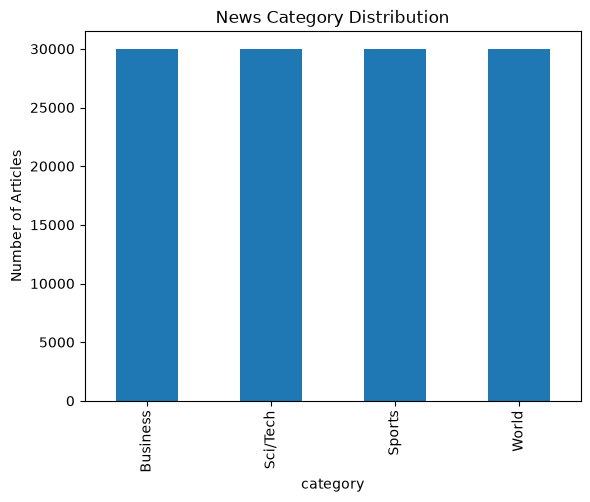

In [29]:
import matplotlib.pyplot as plt 

df["category"].value_counts().plot(kind="bar")

plt.title("News Category Distribution")
plt.xlabel("category")
plt.ylabel("Number of Articles")
plt.show()

In [30]:
x = df["text"]
y = df["label"]

In [31]:
x.head()

0    Wall St. Bears Claw Back Into the Black (Reute...
1    Carlyle Looks Toward Commercial Aerospace (Reu...
2    Oil and Economy Cloud Stocks' Outlook (Reuters...
3    Iraq Halts Oil Exports from Main Southern Pipe...
4    Oil prices soar to all-time record, posing new...
Name: text, dtype: str

In [32]:
y.head()

0    2
1    2
2    2
3    2
4    2
Name: label, dtype: int64

In [33]:
print("X shape:" , x.shape)
print("y shape:" , y.shape)

X shape: (120000,)
y shape: (120000,)


training the validattion data 


In [43]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2, 
    random_state = 42,
    stratify=y

)

understand ?
we are giving function x = 120000 articles 
and y 120000 labels 

the function keep[s each article corrected]

test size = 0.2

that means 20% into validattion test 

why call is x labels in stead of x_test??

AG News already gave us:
train → 120,000
test  →   7,600
Original training data
120,000
        ↓
   ┌───────────┐
   ↓           ↓
96,000       24,000
TRAIN       VALIDATION
   ↓           ↓
Learn       Tune/check


Original AG News test
7,600
   ↓
FINAL 
for random splir = 42  
makes the random split reproducible.
Run the notebook tomorrow → same split.
Someone clones your GitHub project → same split.
There's nothing special about 42; it's simply a commonly used fixed number.

for stratify = y 
keeps the same class proportion for both sets 


In [44]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (96000,)
X_val: (24000,)
y_train: (96000,)
y_val: (24000,)


In [45]:
print(y_train.value_counts(normalize=True))

label
1    0.25
3    0.25
0    0.25
2    0.25
Name: proportion, dtype: float64


turnNING LANGUAGE INTO NUMBER 


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

Why this line?
sklearn is scikit-learn.
feature_extraction contains tools that turn raw data into features a machine-learning model can use.
.text means we're specifically working with text.
TfidfVectorizer is the class that will: English text
    ↓
TF-IDF
    ↓
Numerical features

In [47]:
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english"
)